# **Analisis Exploratorio de Metrobus**

1. Introducción

2. Objetivos

3. Importación de librerías

4. Configuración de Pandas

5. Carga de datos

6. Resumen general
    - dimensiones
    - memoria
    - nulos
    - duplicados

7. Análisis individual

    * 7.1 Viajes
    * 7.2 Mantenimiento
    * 7.3 Incidencias
    * 7.4 Conductores
    * 7.5 Cocheras
    * 7.6 Líneas
    * 7.7 Paradas
    * 7.8 Tarifas
    * 7.9 Vehículos

8. Conclusiones

## **1. Introducción**

## **2. Objetivos**

## **3. Importación de librerías**

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## **4. Configuración de Pandas**

In [118]:
# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar todo el texto en las celdas sin truncar
pd.set_option('display.max_colwidth', None)

## **5. Carga de datos**

In [119]:
# Cargamos los archivos CSV en los DataFrames

# Tablas de hechos
df_viajes = pd.read_csv("../data/raw/fact_viajes.csv")
df_incidencias = pd.read_csv("../data/raw/fact_incidencias.csv")
df_mantenimientos = pd.read_csv("../data/raw/fact_mantenimiento.csv")

# Tablas de dimensión
df_lineas = pd.read_csv("../data/raw/dim_linea.csv")
df_vehiculos = pd.read_csv("../data/raw/dim_vehiculo.csv")
df_conductores = pd.read_csv("../data/raw/dim_conductor.csv")
df_paradas = pd.read_csv("../data/raw/dim_parada.csv")
df_tarifas = pd.read_csv("../data/raw/dim_tarifa.csv")
df_cocheras = pd.read_csv("../data/raw/dim_depot.csv")

## **6. Resumen general**

En este apartado analizamos la estructura de cada tabla para identificar:

* Total de columnas
* Total de filas
* Total de nulos
* Porcentaje de nulos
* Total de duplicados
* Memoria utilizada

In [120]:
dataframes = {
    "viajes": df_viajes,
    "incidencias": df_incidencias,
    "mantenimiento": df_mantenimientos,
    "lineas": df_lineas,
    "vehiculos": df_vehiculos,
    "conductores": df_conductores,
    "paradas": df_paradas,
    "tarifas": df_tarifas,
    "cocheras": df_cocheras
}

In [121]:
# Obtenemos un nuevo DataFrame con los metadatos de todos los datasets
metadatos = {
    'DataFrame': [],
    'Columnas': [],
    'Filas': [],
    'Nulos': [],
    '% Nulos': [],
    'Duplicados': [],
    'Memoria MB': []
}

for name, dataframe in dataframes.items():
    nulos = dataframe.isnull().sum().sum()
    filas = dataframe.shape[0]

    metadatos["DataFrame"].append(name)
    metadatos["Columnas"].append(dataframe.shape[1])
    metadatos["Filas"].append(filas)
    metadatos["Nulos"].append(nulos)
    metadatos["% Nulos"].append(round(((nulos/filas) * 100), 2))
    metadatos["Duplicados"].append(dataframe.duplicated().sum())
    metadatos["Memoria MB"].append(round(dataframe.memory_usage(deep=True).sum() / (1024 **2), 3))

df_estructura_general = pd.DataFrame(metadatos).set_index('DataFrame')
df_estructura_general

,Columnas,Filas,Nulos,% Nulos,Duplicados,Memoria MB
DataFrame,,,,,,
viajes,24,50000,1105,2.21,0,22.212
incidencias,16,4000,0,0.00,0,1.378
mantenimiento,15,876,15,1.71,0,0.318
lineas,7,10,0,0.00,0,0.002
vehiculos,12,45,1,2.22,0,0.011
conductores,10,30,1,3.33,0,0.008
paradas,10,120,2,1.67,0,0.029
tarifas,6,9,0,0.00,0,0.001
cocheras,6,3,0,0.00,0,0.001


## **7. Análisis individual**

En este apartado se realiza un análisis individual de cada tabla del dataset con el objetivo de comprender su estructura, calidad y distribución de los datos.

Para cada columna se analizan los siguientes aspectos:

* Tipo de dato de cada atributo.
* Número total de valores nulos.
* Porcentaje de valores nulos respecto al total de registros.
* Cantidad de valores únicos para conocer la cardinalidad de los datos.
* Moda de cada columna para identificar los valores más repetidos.
* Número total de filas y columnas de cada tabla.
* Valor más frecuente (`top`) y su frecuencia (`freq`) de aparición.
* Medidas estadísticas descriptivas para variables numéricas:
  * Media.
  * Desviación estándar.
  * Moda
  * Valor mínimo.
  * Valor máximo.

Este análisis permite detectar problemas de calidad de datos, identificar posibles valores atípicos y comprender la distribución de las variables antes de realizar las transformaciones y análisis posteriores.

Posteriormente, se realizará un **análisis específico de los valores atípicos (outliers)** presentes en las variables numéricas del DataFrame.

En primer lugar, se generará un **diagrama de caja (Box Plot)** que represente conjuntamente todas las variables numéricas. Esto permitirá obtener una primera visión general de la distribución de los datos y detectar visualmente posibles valores atípicos en cada variable.

A continuación, se utilizarán **histogramas individuales** para analizar con mayor detalle la distribución de cada variable numérica. Mediante estos gráficos se determinará si los datos presentan una distribución  normal o, por el contrario, una distribución no normal. Una vez analizada la distribución de las variables, se seleccionará el método de detección de valores atípicos más adecuado:

* Para las variables que presenten una **distribución no normal**, se empleará el Método del **Rango Intercuartílico (IQR)**.
* Para las variables que presenten una **distribución normal**, se utilizará la **Puntuación Z (Z-Score)**.

In [122]:
def es_numero(columna):
    return columna.dtype in [int, float, bool]

def es_object(columna):
    return columna.dtype in [object, str]

In [123]:
def pasar_int_a_str(lista):
    return [str(n) for n in lista]

def obtener_valores(columna):
    return ", ".join([str(x) for x in columna.dropna().unique()[:3]])

In [124]:
def calcular_nulos(columna):
    return columna.isnull().sum()

def calcular_porcentaje_nulos(columna):
    return round((calcular_nulos(columna)/ columna.size) * 100, 2)

def calcular_valores_unicos(columna):
    return len(columna.unique())

def calcular_top(columna):
    return columna.value_counts().index[0] if es_object(columna) else np.nan

def calcular_frecuencia(columna):
    return columna.value_counts().iloc[0] if es_object(columna) else np.nan

def calcular_media(columna):
    return round( np.mean(columna), 2) if es_numero(columna) else np.nan

def calcular_std(columna):
    return round(np.std(columna), 2) if es_numero(columna) else np.nan

def calcular_moda(columna):
    lista_con_str = pasar_int_a_str(list(columna.mode())[:6])
    resultado = " - ".join(lista_con_str) + " - ..." if len(lista_con_str) > 5 else ("".join(lista_con_str) if len(lista_con_str) == 1 else " - ".join(lista_con_str))
    
    return resultado if es_numero(columna) else np.nan

def calcular_min(columna):
    return columna.min() if es_numero(columna) else np.nan

def calcular_max(columna):
    return columna.max() if es_numero(columna) else np.nan

In [125]:
def crear_tabla_metadatos(df):

    return pd.DataFrame(
                data= {
                        'Columna': df.columns,
                        'Tipo_Dato': df.dtypes,
                        'Valores_Nulos': df.apply(calcular_nulos, axis=0), 
                        'Porcentaje_Nulos': df.apply(calcular_porcentaje_nulos, axis=0),
                        'Valores_Unicos': df.apply(calcular_valores_unicos, axis=0),
                        'Filas': df.shape[0],
                        'Columnas': df.shape[1],
                        'Media': df.apply(calcular_media, axis=0),
                        'Desviacion': df.apply(calcular_std, axis=0),
                        'Moda': df.apply(calcular_moda, axis=0),
                        'Minimo': df.apply(calcular_min, axis=0),
                        'Maximo': df.apply(calcular_max, axis=0),
                        'Top': df.apply(calcular_top, axis=0),
                        'Frecuencia_Moda': df.apply(calcular_frecuencia, axis=0),
                        'Ejemplo de Valores (Max.3)': df.apply(obtener_valores, axis=0)

                }).set_index('Columna').sort_values(by='Tipo_Dato')  # Ordena las columnas por tipo de dato para agrupar los valores estadísticos válidos y evitar la alternancia entre valores y NaN.

In [126]:
def crear_boxplot(df, columna):
    plt.figure(figsize=(10, 6))

    plt.boxplot(
        df[columna].dropna()                                                                          
    )

    plt.title("Distribución de " + columna)
    plt.xlabel(columna)
    
    plt.tight_layout()                                           
    plt.show()

In [127]:
import math

def crear_boxplot_general(df, columnas, nombre_df):

    if df.empty: 
        print("DataFrame vacio")
        return

    nombre_columnas = df.columns
    len_columnas = len(nombre_columnas)

    filas = math.ceil(len_columnas / columnas)        
                                               
    fig, axs = plt.subplots(
        nrows= filas, 
        ncols= columnas, 
        figsize=(12, 8)         
    ) 

    fig.suptitle(                               
        "Boxplot de las variables numéricas " + nombre_df,
        fontsize= 14,
        fontweight="bold"
    )

    contador = 0

    # TODO REFACTORIZARLO 
    if filas > 1: 
        for i in range(filas):
            for c in range(columnas):
                nombre = nombre_columnas[contador]

                sns.boxplot(                               
                        data= df[nombre], 
                        ax= axs[i, c]           
                    )
                
                axs[i, c].set_title(nombre, fontsize=12)
                axs[i, c].xaxis.set_visible(False)               
                axs[i, c].yaxis.set_visible(False)   

                if (contador == len_columnas - 1):
                    return
                
                contador += 1   
                
    else:
        for c in range(columnas):
            nombre = nombre_columnas[contador]

            sns.boxplot(                               
                    data= df[nombre], 
                    ax= axs[c]
                )
            
            axs[c].set_title(nombre, fontsize=12)
            axs[c].xaxis.set_visible(False)               
            axs[c].yaxis.set_visible(False)   

            if (contador == len_columnas - 1):
                return
            
            contador += 1   

    # Configuracion General Grafica
    axs.xaxis.set_visible(False)
    axs.yaxis.set_visible(False)

    axs.spines['left'].set_visible(False)
    axs.spines['top'].set_visible(False)
    axs.spines['bottom'].set_visible(False)
    axs.spines['right'].set_visible(False)



    plt.tight_layout()
    plt.show()

In [128]:
def crear_histograma(df, columna):
    plt.figure(figsize=(10, 5))

    plt.hist(
        df[columna].dropna(), 
        bins="auto", 
        linewidth= 0.75,
        edgecolor="black"    
        )

    plt.title("Distribución de " + columna)
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

In [129]:
def calcular_z_score(df, columna, z_threshold = 2.8):
    df = df.dropna(how='all', subset=[columna])
    df_z_score = df[np.abs(stats.zscore(df[columna].dropna())) > z_threshold][columna]
    
    print("Valores atípicos detectados con Z-score: " + str(df_z_score.size))
    return df_z_score

In [130]:
def calcular_iqr(df, columna):
    df = df.dropna(how='all', subset=[columna])

    iqr_value = stats.iqr(df[columna])
    q1, q3 = np.quantile(df[columna], [0.25, 0.75])

    lower = q1 - 1.5 * iqr_value
    upper = q3 + 1.5 * iqr_value

    df_iqr = df[(df[columna] < lower) | (df[columna]> upper)][columna]
    print("\nValores atípicos detectados con IQR: " + str(df_iqr.size))
    
    return df_iqr

## **7.1 Viajes**

### **7.1.1 Analisis Inicial**

In [131]:
df_viajes.head(3)

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,False,Tarde punta,17:50,18:09,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,False,Manana punta,07:10,07:23,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,False,Valle manana,12:30,12:30,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3


In [132]:
df_viajes_metadatos = crear_tabla_metadatos(df_viajes)
df_viajes_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
viaje_completado,bool,0,0.00,2,50000,24,0.98,0.14,True,False,True,NaN,NaN,"True, False"
es_festivo,bool,0,0.00,2,50000,24,0.28,0.45,False,False,True,NaN,NaN,"False, True"
viaje_id,int64,0,0.00,50000,50000,24,25000.50,14433.76,1 - 2 - 3 - 4 - 5 - 6 - ...,1,50000,NaN,NaN,"1, 2, 3"
duracion_real_min,int64,0,0.00,105,50000,24,62.60,23.85,39,25,129,NaN,NaN,"73, 67, 35"
retraso_salida_min,int64,0,0.00,55,50000,24,3.89,6.76,0,-99,50,NaN,NaN,"19, 13, 0"
mes,int64,0,0.00,12,50000,24,6.52,3.45,8,1,12,NaN,NaN,"8, 5, 3"
anno,int64,0,0.00,3,50000,24,2023.00,0.82,2024,2022,2024,NaN,NaN,"2023, 2024, 2022"
tarifa_predominante_id,int64,0,0.00,9,50000,24,3.61,2.16,3,1,9,NaN,NaN,"4, 2, 3"
parada_destino_id,int64,0,0.00,80,50000,24,80.45,23.13,104,41,120,NaN,NaN,"116, 48, 110"


In [133]:
df_viajes.retraso_salida_min.min()

np.int64(-99)

In [134]:
df_viajes.dia_semana.unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday',
       'Saturday', 'SATURDAY', 'SUNDAY', 'FRIDAY', 'TUESDAY', 'WEDNESDAY',
       'MONDAY', 'THURSDAY'], dtype=object)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_viajes` permite concluir que, en términos generales, la tabla presenta una buena calidad de los datos, ya que la mayoría de las columnas no contienen valores nulos y el rango de los valores es coherente. No obstante, se han identificado varios aspectos que requieren una revisión más detallada en las siguientes fases del EDA: 

* La columna **dia_semana** presenta 14 valores únicos, un rango superior a lo esperado para una variable que representa los días de la semana. 

* La columna **consumo** contiene 1.065 valores nulos (2,13 %), siendo la variable con mayor cantidad de datos ausentes. Asimismo, la columna **pasajeros_subidos** presenta un total de 40 valores nulos (0,08 %).

* También se ha detectado que la variable **retraso_salida_min** tiene un valor mínimo de -99 minutos, un dato poco plausible desde el punto de vista operativo.

Por último, las columnas **fecha, hora_salida_real, hora_llegada_real y hora_salida_prog** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

### **7.1.2 Outliers**

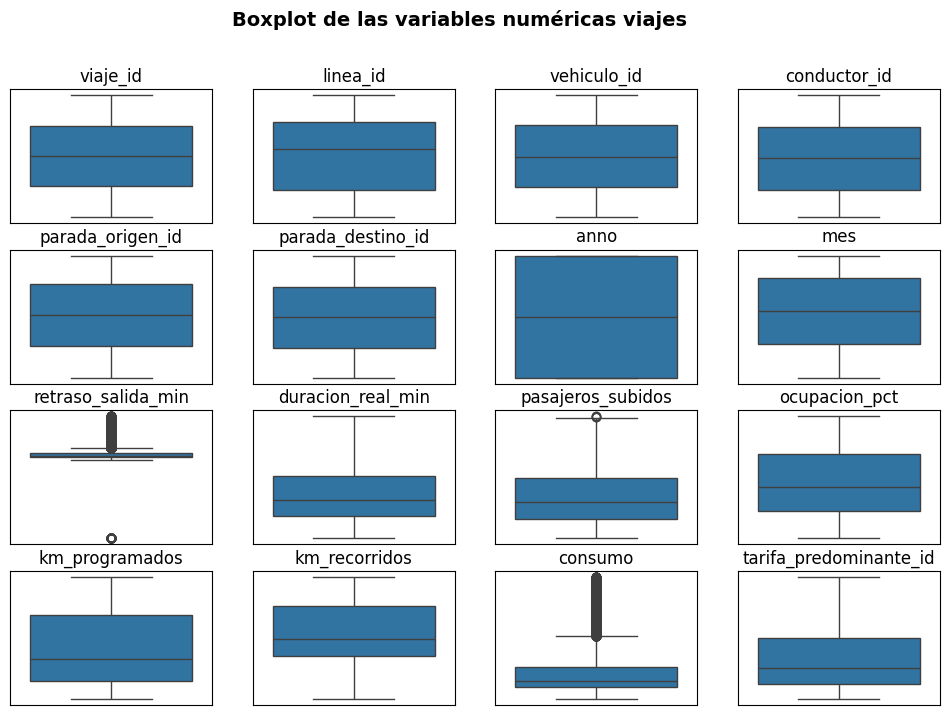

In [135]:
crear_boxplot_general(df_viajes.select_dtypes(include="number"), 4, "viajes")

Observando las diferentes gráficas, se puede apreciar que las variables **`retraso salida (min)`**, **`Pasajeros subidos`** y **`Consumo`** presentan valores atípicos (outliers). Por este motivo, se procederá a realizar un análisis individualizado de estas variables para determinar su origen y evaluar su impacto en el análisis de los datos.

#### **7.1.2.1 Consumo**

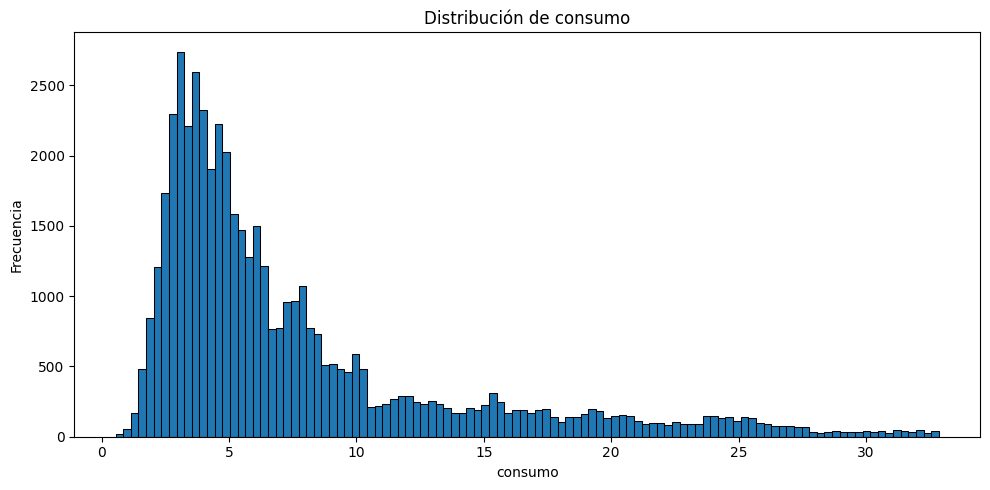

In [136]:
crear_histograma(df_viajes , "consumo")

In [137]:
calcular_iqr(df_viajes, "consumo")


Valores atípicos detectados con IQR: 4863


7        19.90
21       17.31
22       18.40
27       25.13
79       29.94
         ...  
49916    19.07
49932    21.66
49944    23.61
49945    26.12
49958    17.78
Name: consumo, Length: 4863, dtype: float64

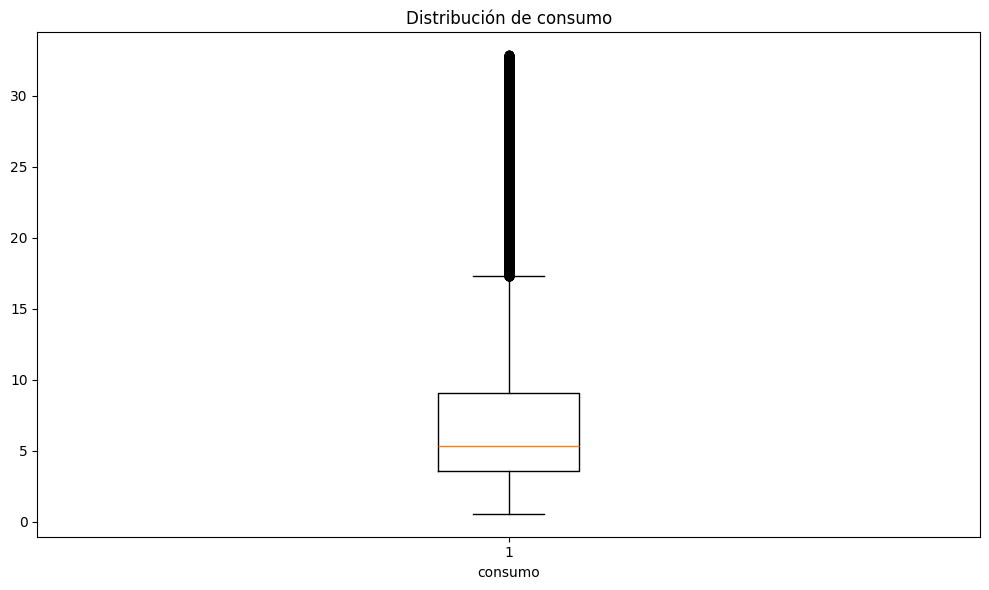

In [138]:
crear_boxplot(df_viajes, "consumo")

#### **7.1.2.2 Pasajeros Subidos**

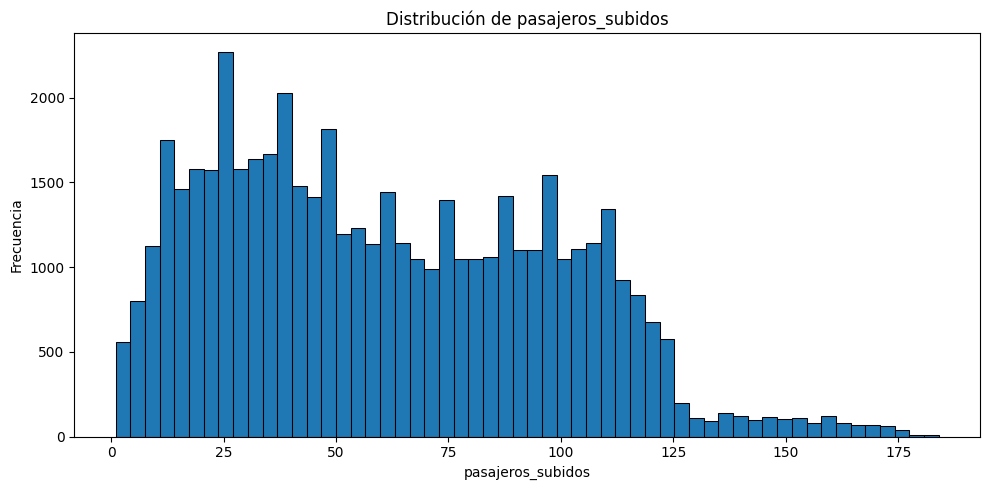

In [139]:
crear_histograma(df_viajes, "pasajeros_subidos")

In [140]:
calcular_iqr(df_viajes, "pasajeros_subidos")


Valores atípicos detectados con IQR: 4


12730    184.0
14887    183.0
28552    184.0
43111    183.0
Name: pasajeros_subidos, dtype: float64

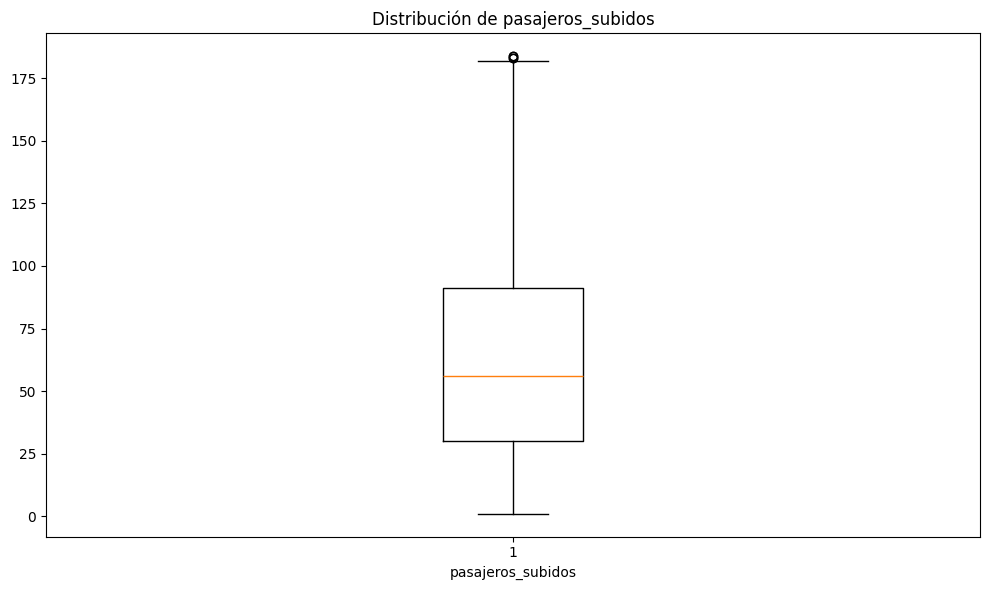

In [141]:
crear_boxplot(df_viajes, "pasajeros_subidos")

#### **7.1.2.3 Retraso Salida Min**

In [142]:
df_retraso_sin_min = df_viajes[df_viajes["retraso_salida_min"] > -20]

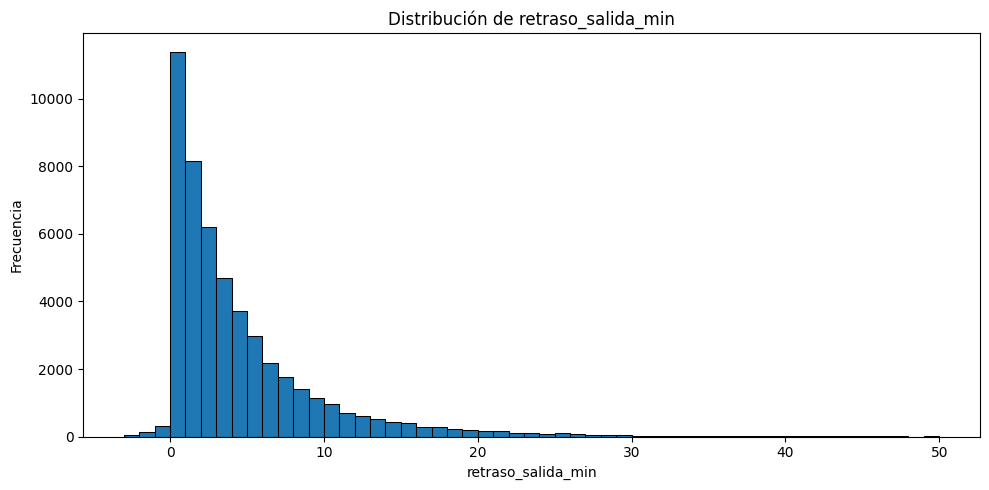

In [143]:
crear_histograma(df_retraso_sin_min, "retraso_salida_min") # Excluidmos el valor -99

In [144]:
calcular_iqr(df_retraso_sin_min, "retraso_salida_min")


Valores atípicos detectados con IQR: 4147


0        19
1        13
24       13
25       14
27       18
         ..
49956    17
49967    16
49968    23
49972    12
49988    12
Name: retraso_salida_min, Length: 4147, dtype: int64

In [145]:
calcular_z_score(df_retraso_sin_min, "retraso_salida_min")

Valores atípicos detectados con Z-score: 1190


36       29
42       24
46       25
82       32
150      20
         ..
49741    27
49813    21
49875    21
49940    25
49968    23
Name: retraso_salida_min, Length: 1190, dtype: int64

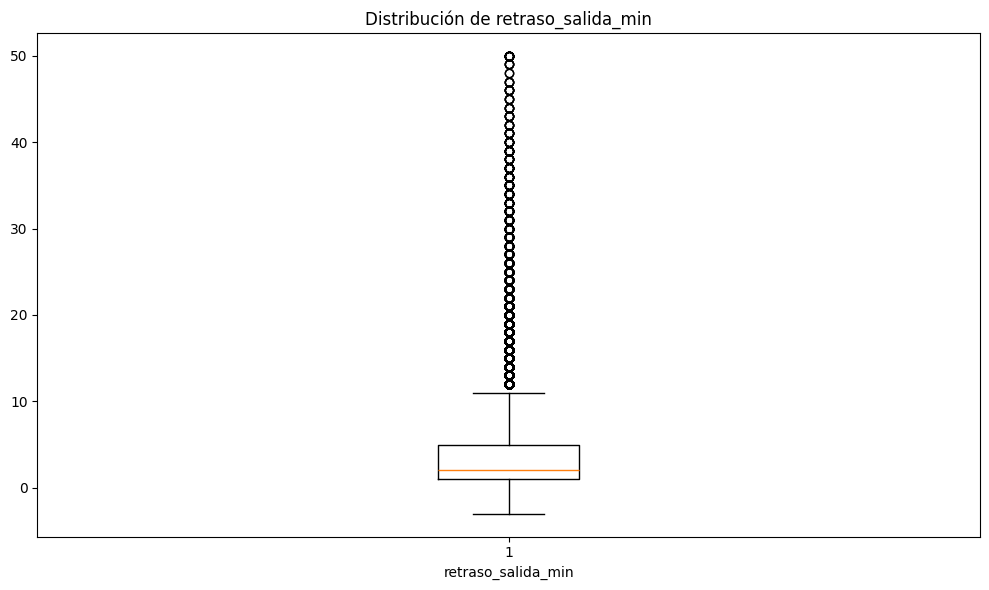

In [146]:
crear_boxplot(df_retraso_sin_min, "retraso_salida_min")

## **7.2 Mantenimiento**

### **7.2.1 Analisis Inicial**

In [147]:
df_mantenimientos.head(3)

,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
0,1,1,1,2024-07-24,2024-07-25,2024,7,Cambio aceite,Preventivo,False,1,278454,218.70,TallerBus Norte,0
1,2,1,1,2023-02-08,2023-02-09,2023,2,Cambio neumaticos,Preventivo,False,1,240059,1068.93,TallerBus Norte,0
2,3,1,1,2024-10-28,2024-10-29,2024,10,Cambio neumaticos,Preventivo,False,1,493071,722.19,Taller Oficial Mercedes,0


In [148]:
df_mantenimientos_metadatos = crear_tabla_metadatos(df_mantenimientos)
df_mantenimientos_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
es_correctivo,bool,0,0.00,2,876,15,0.38,0.49,False,False,True,NaN,NaN,"False, True"
mantenimiento_id,int64,0,0.00,876,876,15,438.50,252.88,1 - 2 - 3 - 4 - 5 - 6 - ...,1,876,NaN,NaN,"1, 2, 3"
vehiculo_id,int64,0,0.00,45,876,15,22.71,12.83,18 - 19 - 26,1,45,NaN,NaN,"1, 2, 3"
depot_id,int64,0,0.00,3,876,15,1.85,0.78,1,1,3,NaN,NaN,"1, 2, 3"
anno,int64,0,0.00,4,876,15,2023.25,0.88,2024,2022,2025,NaN,NaN,"2024, 2023, 2022"
mes,int64,0,0.00,12,876,15,6.28,3.67,1,1,12,NaN,NaN,"7, 2, 10"
dias_fuera_servicio,int64,0,0.00,11,876,15,1.90,1.96,1,0,10,NaN,NaN,"1, 2, 0"
km_en_revision,int64,0,0.00,876,876,15,277372.78,155954.86,10222 - 10242 - 10393 - 11101 - 11841 - 12536 - ...,10222,549625,NaN,NaN,"278454, 240059, 493071"
garantia_meses,int64,0,0.00,4,876,15,2.08,3.87,0,0,12,NaN,NaN,"0, 6, 12"


In [149]:
df_mantenimientos.coste_eur[df_mantenimientos.coste_eur < 0.00].unique()

array([ -866.9 , -1077.87,  -193.6 ,  -211.69,  -222.12, -1047.04,
        -810.99,  -361.3 ,  -786.21, -2942.78,  -233.91,  -349.48,
        -223.52, -1058.18,  -506.81, -4083.03, -1051.12,  -297.65,
        -353.61, -1065.44,  -405.2 ,  -347.52,  -402.29,  -806.4 ,
        -150.88])

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame df_mantenimiento permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* Se ha detectado una discrepancia temporal en los datos, ya que la columna **anno** contiene registros correspondientes al año 2025, mientras que la información proporcionada indica que los archivos CSV representan datos históricos de MetroBus comprendidos entre los años 2022 y 2024.

*  La columna **coste_euros** presenta valores negativos, un comportamiento que no resulta coherente desde el punto de vista operativo.

* La columna **categoria** presenta 15 valores nulos, lo que representa aproximadamente un 1,71 % del total de registros.

Por ultimo, Las columnas relacionadas con **fechas** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

### **7.2.2 Outliers**

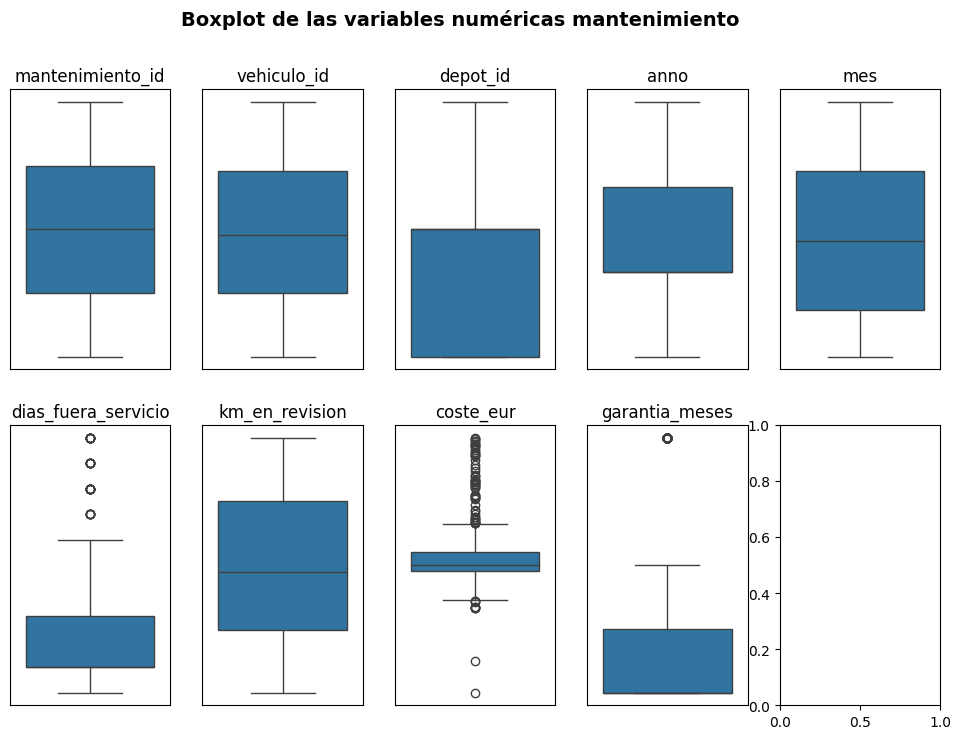

In [150]:
crear_boxplot_general(df_mantenimientos.select_dtypes(include="number"), 5, "mantenimiento")

Observando las diferentes gráficas, se puede apreciar que las variables **`Dias fuera de servicio`**, **`Coste euros`** y **`Garantia meses`** presentan valores atípicos (outliers). Por este motivo, se procederá a realizar un análisis individualizado de estas variables para determinar su origen y evaluar su impacto en el análisis de los datos.

#### **7.2.2.1 Dias fuera de servicio**

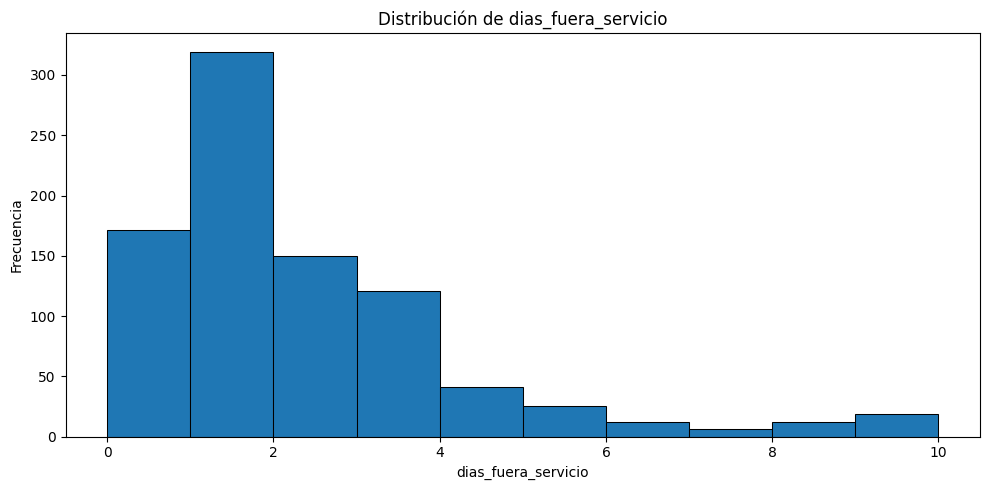

In [151]:
crear_histograma(df_mantenimientos, "dias_fuera_servicio")

In [152]:
calcular_iqr(df_mantenimientos, "dias_fuera_servicio")


Valores atípicos detectados con IQR: 37


40      8
42      9
57     10
103     9
132     8
136    10
149    10
173     8
202     8
206    10
218     9
233     9
235    10
260     8
262     7
271     7
280     9
281     8
284     7
292    10
315     8
320     9
328     8
400     7
403    10
476     8
510     8
551     9
566    10
596     8
679    10
719    10
741     7
781     9
816    10
850     7
867     8
Name: dias_fuera_servicio, dtype: int64

In [153]:
calcular_z_score(df_mantenimientos, "dias_fuera_servicio")

Valores atípicos detectados con Z-score: 31


40      8
42      9
57     10
103     9
132     8
136    10
149    10
173     8
202     8
206    10
218     9
233     9
235    10
260     8
280     9
281     8
292    10
315     8
320     9
328     8
403    10
476     8
510     8
551     9
566    10
596     8
679    10
719    10
781     9
816    10
867     8
Name: dias_fuera_servicio, dtype: int64

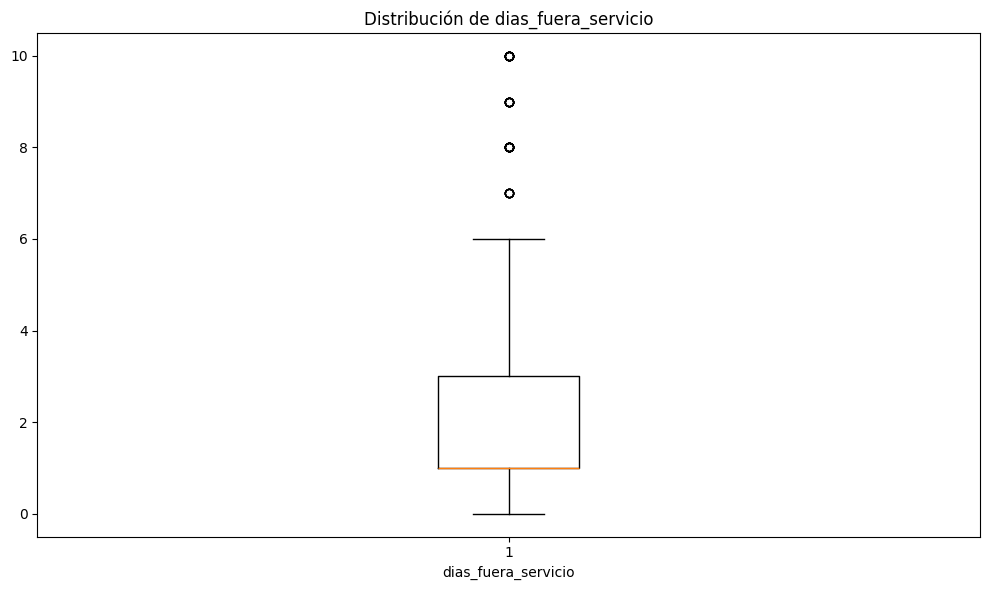

In [154]:
crear_boxplot(df_mantenimientos, "dias_fuera_servicio")

#### **7.2.2.2 Coste euros**

In [155]:
df_sin_valores_negativos = df_mantenimientos[ df_mantenimientos.coste_eur > 0] # Excluimos los valores negativos

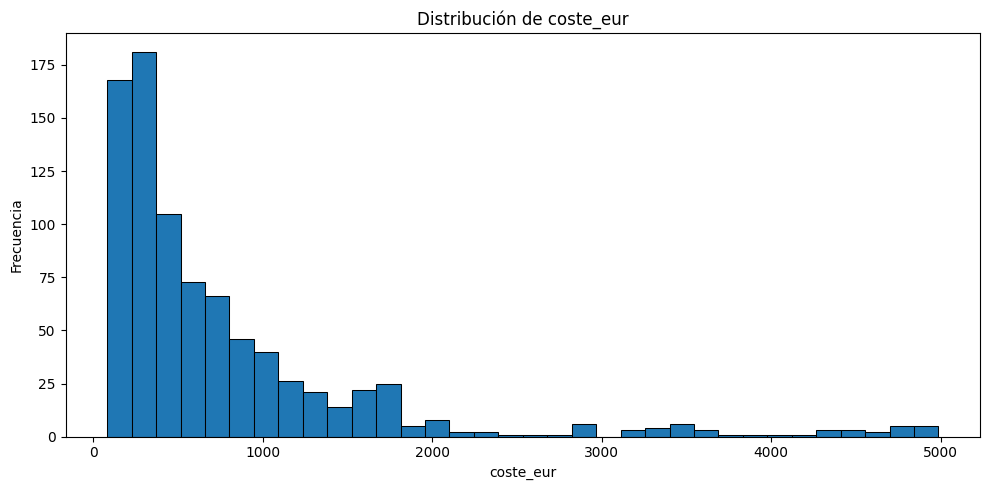

In [156]:
crear_histograma(df_sin_valores_negativos, "coste_eur")

In [157]:
calcular_iqr(df_sin_valores_negativos, "coste_eur")


Valores atípicos detectados con IQR: 54


33     4569.24
40     2187.44
42     4849.40
57     2389.38
102    3467.92
121    3312.16
136    4631.27
149    2852.34
173    2286.48
178    2598.16
200    3234.38
202    2414.39
218    3402.59
235    3480.93
239    2922.86
255    3651.67
257    2948.64
258    4019.28
260    3618.09
262    2894.92
271    3503.10
280    4395.06
281    2048.58
291    4777.67
292    2837.23
320    4492.96
325    4437.77
328    3930.72
379    2949.96
403    4894.29
419    3340.01
429    3585.09
436    4421.06
438    3243.47
476    3301.23
479    4350.76
510    2099.03
535    3205.40
542    4351.87
551    4968.74
585    3461.59
633    3404.46
650    4987.72
679    3345.40
694    4704.44
741    2160.30
742    3814.45
743    2084.04
781    4945.61
806    2799.25
814    4193.52
816    4789.20
850    4702.65
867    4722.02
Name: coste_eur, dtype: float64

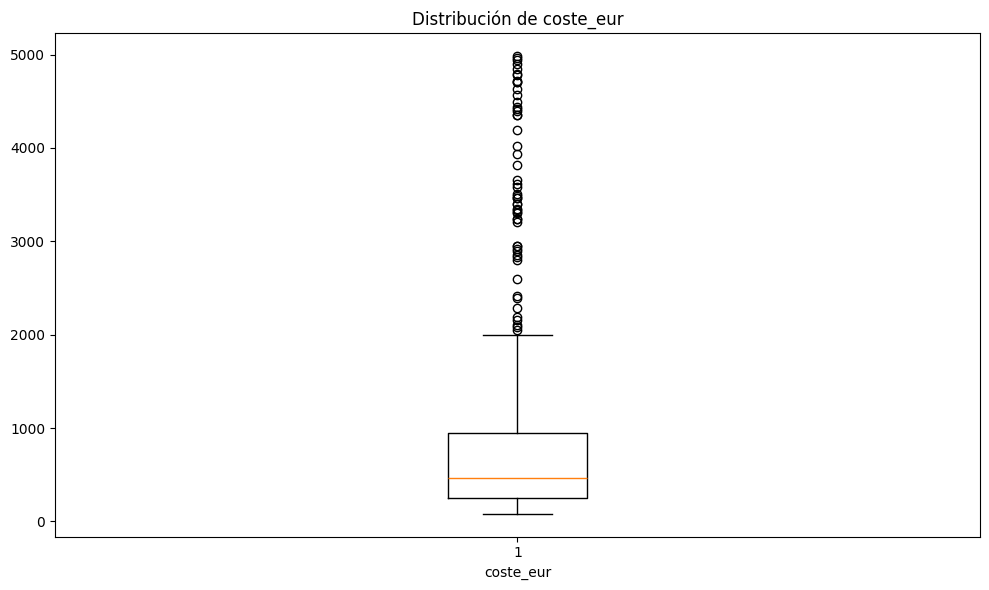

In [159]:
crear_boxplot(df_sin_valores_negativos, "coste_eur")

#### **7.2.2.3 Garantia meses**

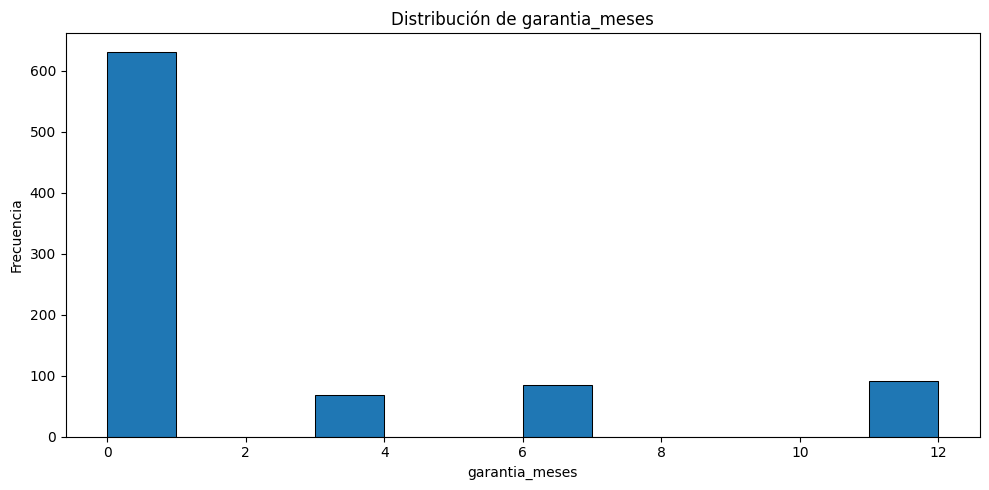

In [160]:
crear_histograma(df_mantenimientos, "garantia_meses")

In [161]:
calcular_iqr(df_mantenimientos, "garantia_meses")


Valores atípicos detectados con IQR: 92


7      12
12     12
16     12
41     12
76     12
       ..
838    12
848    12
852    12
857    12
867    12
Name: garantia_meses, Length: 92, dtype: int64

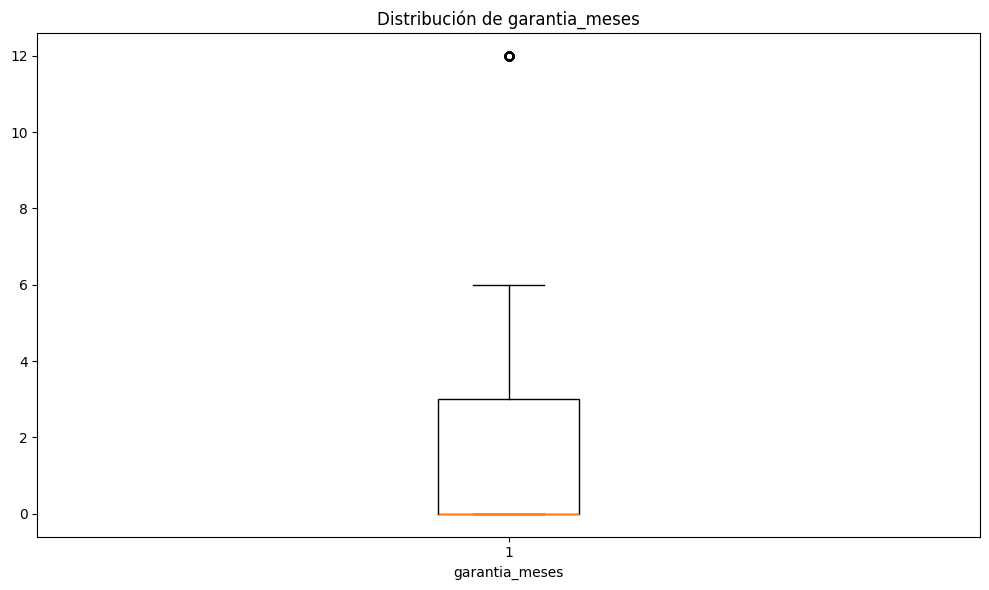

In [162]:
crear_boxplot(df_mantenimientos, "garantia_meses")

## **7.3 Incidencias**

### **7.3.1 Analisis Inicial**

In [163]:
df_incidencias.head(3)

,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
0,1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.00
1,2,9428,21,21,6,2023-02-16,2023,2,20:42,Fallo electrico,Vehiculo,Alta,True,62,False,575.51
2,3,200,33,5,8,2022-01-20,2022,1,06:21,Accidente leve,Seguridad,Alta,True,29,True,3318.00


In [164]:
df_incidencias_metadatos = crear_tabla_metadatos(df_incidencias)
df_incidencias_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
requiere_retirada,bool,0,0.0,2,4000,16,0.50,0.50,True,False,True,NaN,NaN,"True, False"
vehiculo_sustituto,bool,0,0.0,2,4000,16,0.36,0.48,False,False,True,NaN,NaN,"False, True"
incidencia_id,int64,0,0.0,4000,4000,16,2000.50,1154.70,1 - 2 - 3 - 4 - 5 - 6 - ...,1,4000,NaN,NaN,"1, 2, 3"
viaje_id,int64,0,0.0,4000,4000,16,24813.57,14309.33,5 - 63 - 104 - 145 - 148 - 168 - ...,5,49989,NaN,NaN,"33554, 9428, 200"
vehiculo_id,int64,0,0.0,42,4000,16,21.34,12.14,9,1,42,NaN,NaN,"39, 21, 33"
conductor_id,int64,0,0.0,28,4000,16,14.62,8.11,22,1,28,NaN,NaN,"11, 21, 5"
linea_id,int64,0,0.0,10,4000,16,5.56,2.85,7,1,10,NaN,NaN,"4, 6, 8"
anno,int64,0,0.0,3,4000,16,2023.03,0.81,2024,2022,2024,NaN,NaN,"2022, 2023, 2024"
mes,int64,0,0.0,12,4000,16,6.55,3.48,8,1,12,NaN,NaN,"6, 2, 1"


In [165]:
df_incidencias[df_incidencias.coste_estimado_eur == 0].head(3)

,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
0,1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.0
7,8,49499,24,24,5,2023-03-03,2023,3,22:20,Obras calzada,Externo,Media,False,5,False,0.0
8,9,4145,30,2,5,2024-05-02,2024,5,20:30,Huelga parcial,Operacional,Alta,True,85,True,0.0


## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_incidencias` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **coste_estimado_eur** presenta valores iguales a 0.00, un comportamiento que apriori no resulta coherente desde el punto de vista operativo.

* Las columnas relacionadas con **fechas** y **horas** se encuentran almacenadas como tipo object, siendo el tipo de dato más adecuado para estas columnas datetime o time.

### **7.3.2 Outliers**

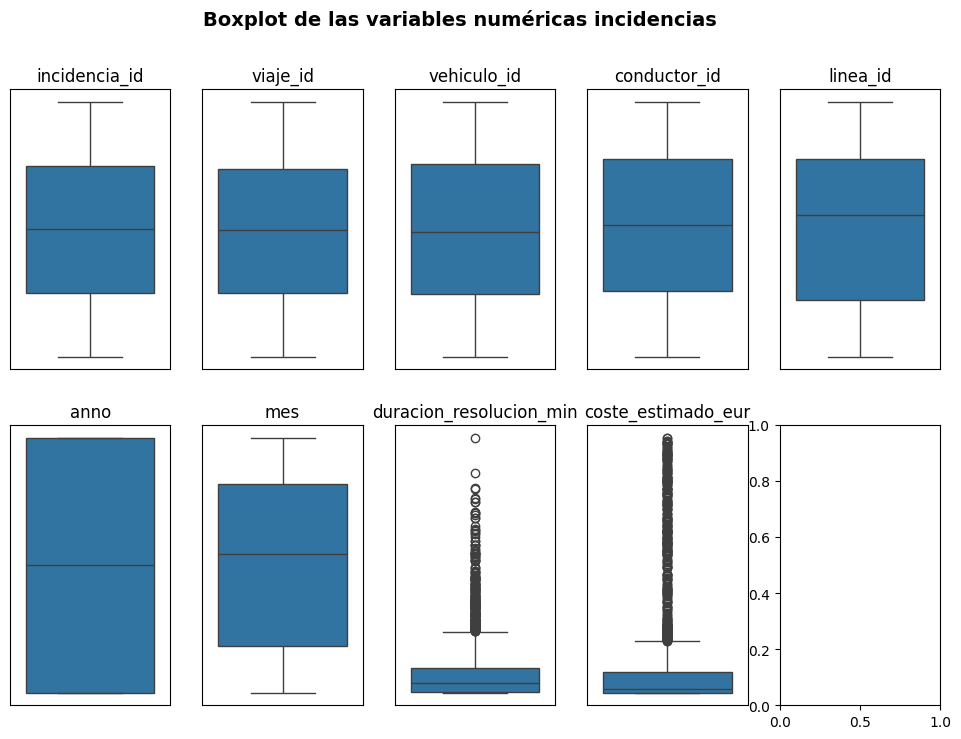

In [166]:
crear_boxplot_general(df_incidencias.select_dtypes(include="number"), 5, "incidencias")

Observando las diferentes gráficas, se puede apreciar que las variables **`Duracion Resolucion (min)`** y **`Coste Estimado euros`** presentan valores atípicos (outliers). Por este motivo, se procederá a realizar un análisis individualizado de estas variables para determinar su origen y evaluar su impacto en el análisis de los datos.

#### **7.3.2.1 Duracion resolucion (min)**

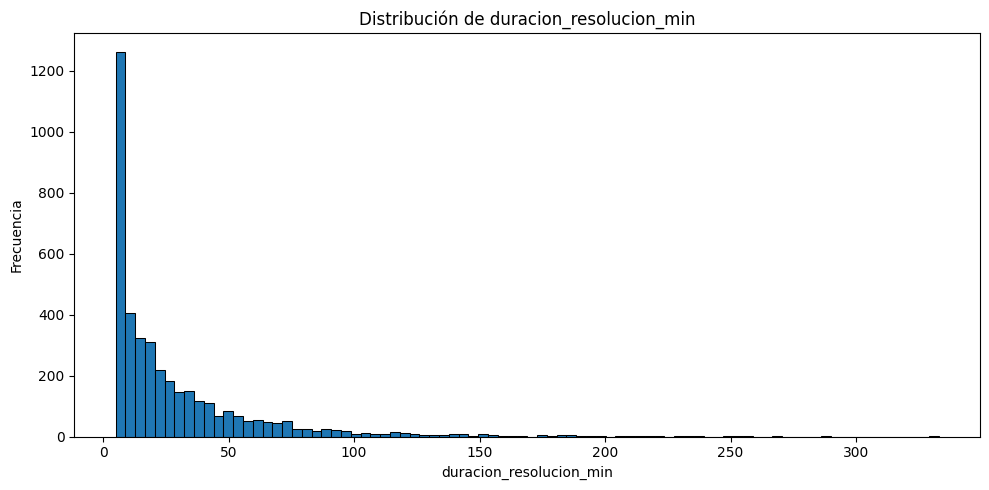

In [167]:
crear_histograma(df_incidencias, "duracion_resolucion_min")

In [169]:
calcular_z_score(df_incidencias, "duracion_resolucion_min")

Valores atípicos detectados con Z-score: 105


48      134
149     184
204     133
216     238
260     176
       ... 
3905    128
3928    166
3937    132
3978    181
3979    154
Name: duracion_resolucion_min, Length: 105, dtype: int64

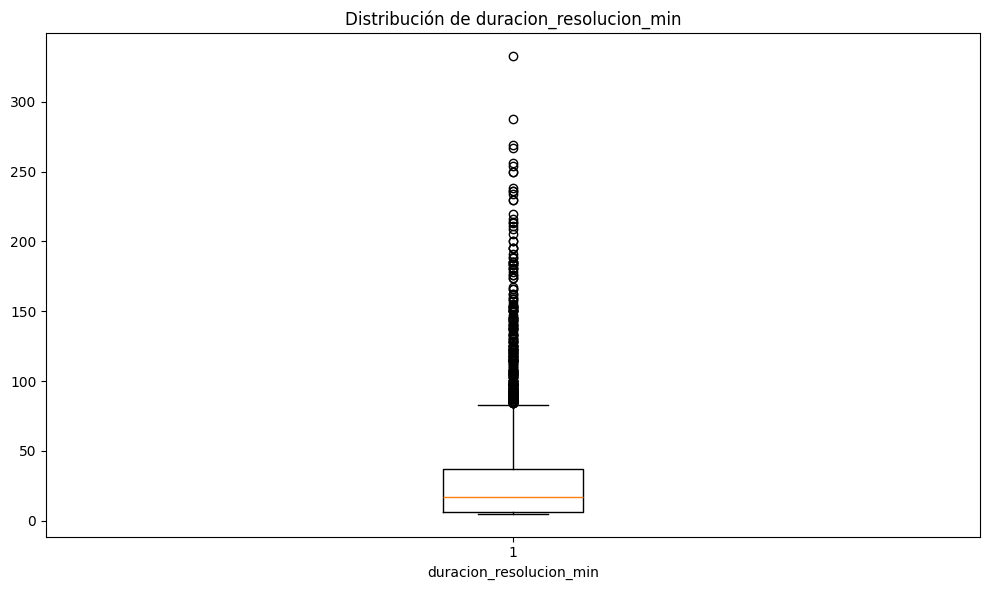

In [170]:
crear_boxplot(df_incidencias, "duracion_resolucion_min")

### **7.3.2.1 Coste estimado euros**

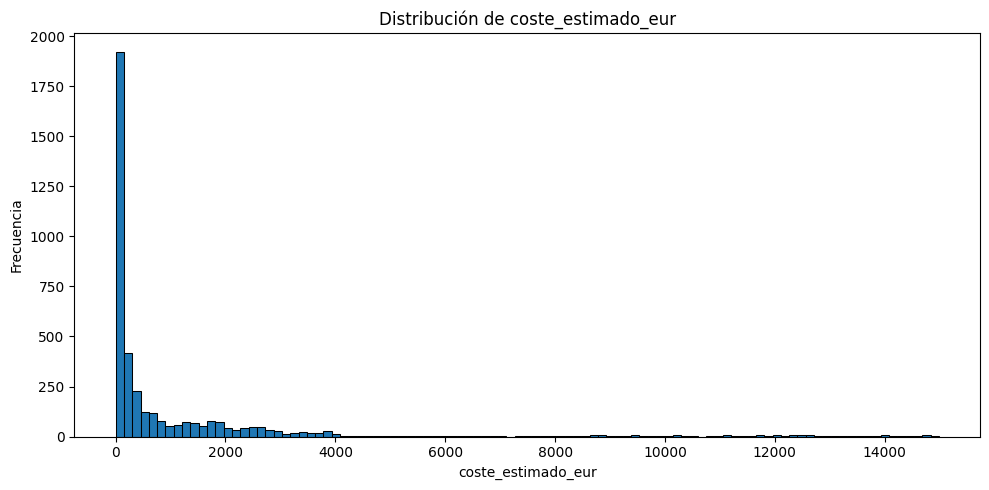

In [171]:
crear_histograma(df_incidencias, "coste_estimado_eur")

In [172]:
calcular_iqr(df_incidencias, "coste_estimado_eur")


Valores atípicos detectados con IQR: 386


2        3318.00
10       3908.61
13      12247.12
39       3607.16
47      14622.86
          ...   
3946    11187.82
3973     3440.82
3974     8685.02
3975     3566.75
3995     9816.47
Name: coste_estimado_eur, Length: 386, dtype: float64

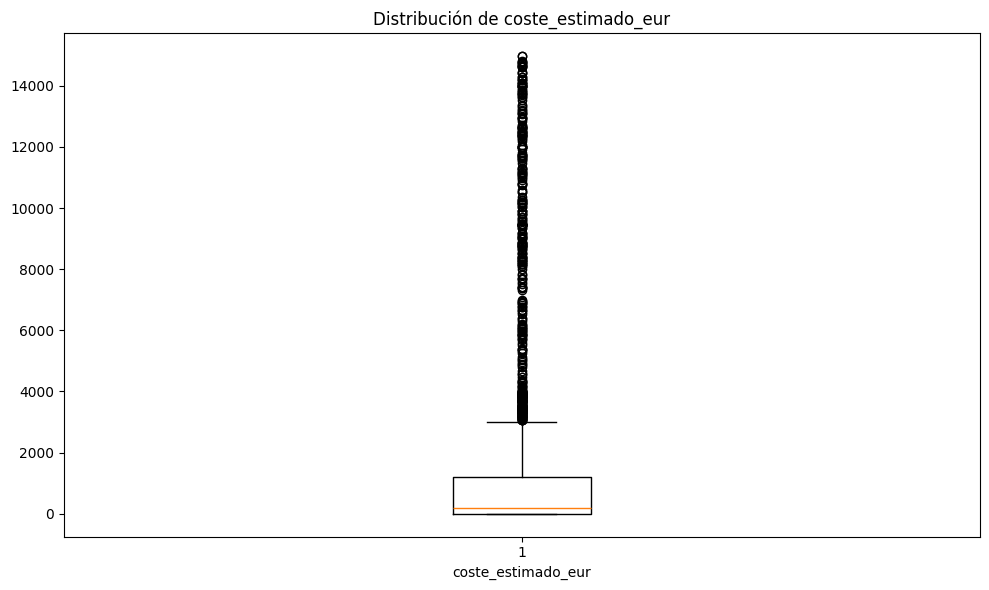

In [174]:
crear_boxplot(df_incidencias, "coste_estimado_eur")

## **7.4 Conductores**

### **7.4.1 Analisis Inicial**

In [175]:
df_conductores.head(3)

,conductor_id,nombre,anno_incorporacion,antiguedad_anos,turno_habitual,depot_id,formacion,licencia_tipo,activo,ausencias_2024
0,1,Carlos Garcia,2009,15.0,Partido,3,Basica,D,True,14
1,2,Maria Lopez,2013,11.0,Noche (22-06h),1,Basica,D,True,9
2,3,Juan Martinez,2008,16.0,Manana (06-14h),2,Completa,D+E,True,6


In [176]:
df_conductores_metadatos = crear_tabla_metadatos(df_conductores)
df_conductores_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
activo,bool,0,0.00,2,30,10,0.93,0.25,True,False,True,NaN,NaN,"True, False"
conductor_id,int64,0,0.00,30,30,10,15.50,8.66,1 - 2 - 3 - 4 - 5 - 6 - ...,1,30,NaN,NaN,"1, 2, 3"
anno_incorporacion,int64,0,0.00,15,30,10,2013.50,5.44,2008 - 2019,2005,2023,NaN,NaN,"2009, 2013, 2008"
depot_id,int64,0,0.00,3,30,10,2.17,0.82,3,1,3,NaN,NaN,"3, 1, 2"
ausencias_2024,int64,0,0.00,13,30,10,8.63,4.96,15,0,15,NaN,NaN,"14, 9, 6"
antiguedad_anos,float64,1,3.33,15,30,10,10.55,5.52,5.0 - 16.0,1.0,19.0,NaN,NaN,"15.0, 11.0, 16.0"
nombre,object,0,0.00,30,30,10,NaN,NaN,NaN,NaN,NaN,Carlos Garcia,1.0,"Carlos Garcia, Maria Lopez, Juan Martinez"
turno_habitual,object,0,0.00,5,30,10,NaN,NaN,NaN,NaN,NaN,Noche (22-06h),8.0,"Partido, Noche (22-06h), Manana (06-14h)"
formacion,object,0,0.00,4,30,10,NaN,NaN,NaN,NaN,NaN,Basica + Articulado,10.0,"Basica, Completa, Basica + Articulado"


In [177]:
df_conductores['turno_habitual'].unique()

array(['Partido', 'Noche (22-06h)', 'Manana (06-14h)', 'manana',
       'Tarde (14-22h)'], dtype=object)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_conductores` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* Se ha detectado una discrepancia temporal en los datos, ya que la columna **anno** contiene registros correspondientes al año 2025, mientras que la información proporcionada indica que los archivos CSV representan datos históricos de MetroBus comprendidos entre los años 2022 y 2024. 

* La variable **turno_habitual** presenta una inconsistencia en la codificación de categorías, ya que aparecen los valores Manana (06-14h) y manana, que representan el mismo turno.

### **7.4.2 Outliers**

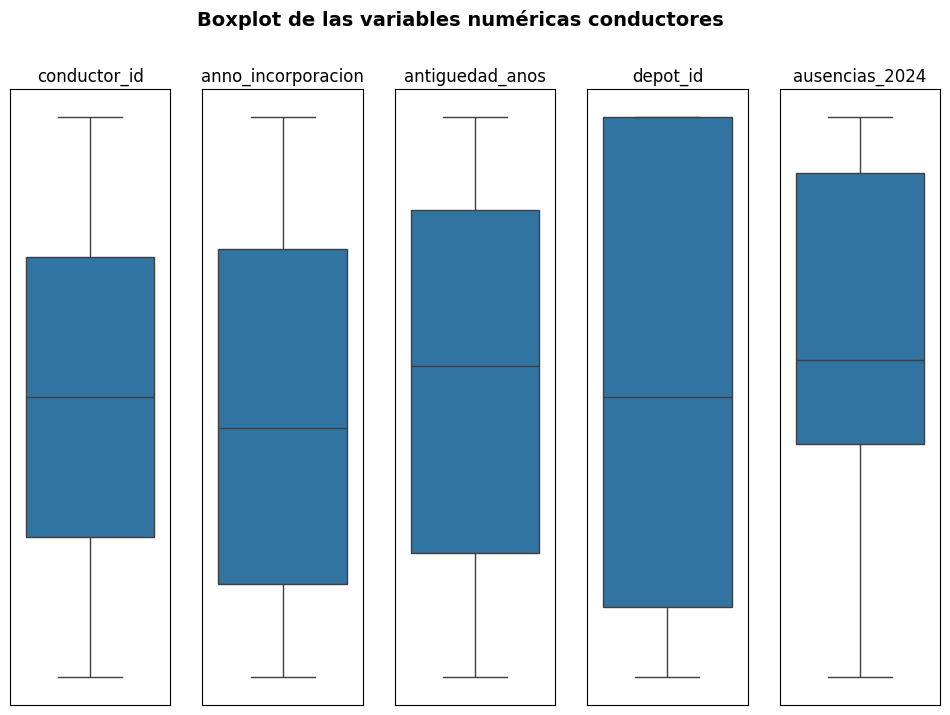

In [178]:
crear_boxplot_general(df_conductores.select_dtypes(include="number"), 5, "conductores")

Observando las diferentes gráficas, se puede apreciar que las variables **no presentan valores atípicos** (outliers). Por este motivo, no se procederá a realizar un análisis individualizado de estas variables.

## **7.5 Cocheras**

### **7.5.1 Analisis Inicial**

In [179]:
df_cocheras.head(3)

,depot_id,nombre,barrio,latitud,longitud,capacidad_vehiculos
0,1,Cochera Norte,Barrio Norte,40.440,-3.720,20
1,2,Cochera Central,Centro,40.418,-3.700,15
2,3,Cochera Sur,Barrio Sur,40.395,-3.695,12


In [180]:
df_cocheras_metadatos = crear_tabla_metadatos(df_cocheras)
df_cocheras_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
depot_id,int64,0,0.0,3,3,6,2.00,0.82,1 - 2 - 3,1.000,3.000,NaN,NaN,"1, 2, 3"
capacidad_vehiculos,int64,0,0.0,3,3,6,15.67,3.30,12 - 15 - 20,12.000,20.000,NaN,NaN,"20, 15, 12"
latitud,float64,0,0.0,3,3,6,40.42,0.02,40.395 - 40.418 - 40.44,40.395,40.440,NaN,NaN,"40.44, 40.418, 40.395"
longitud,float64,0,0.0,3,3,6,-3.70,0.01,-3.72 - -3.7 - -3.695,-3.720,-3.695,NaN,NaN,"-3.72, -3.7, -3.695"
nombre,object,0,0.0,3,3,6,NaN,NaN,NaN,NaN,NaN,Cochera Norte,1.0,"Cochera Norte, Cochera Central, Cochera Sur"
barrio,object,0,0.0,3,3,6,NaN,NaN,NaN,NaN,NaN,Barrio Norte,1.0,"Barrio Norte, Centro, Barrio Sur"


## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_cocheras` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

### **7.5.2 Outliers**

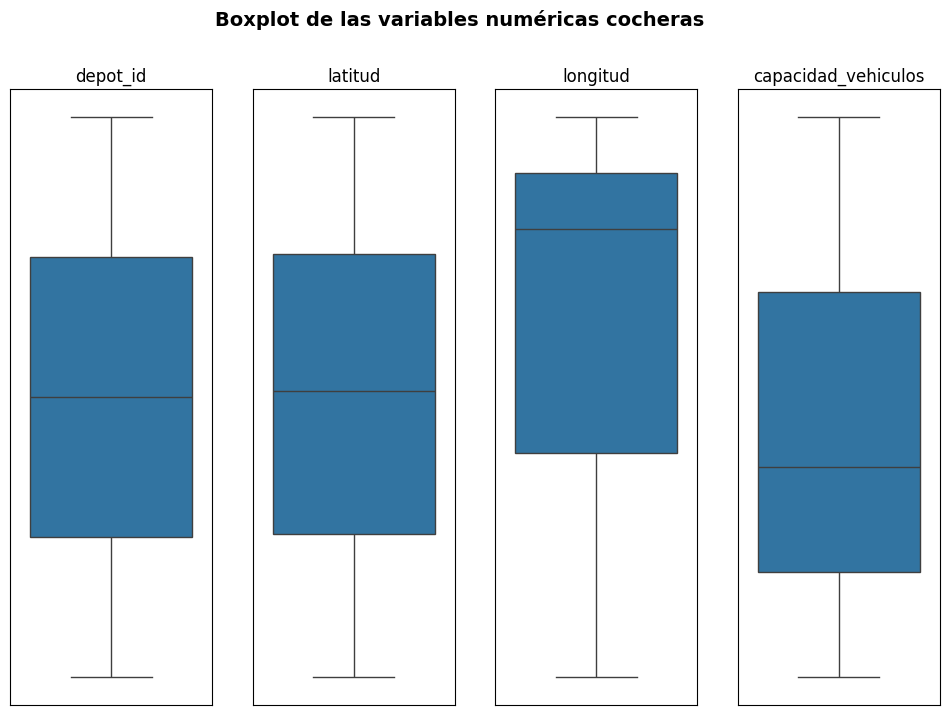

In [181]:
crear_boxplot_general(df_cocheras.select_dtypes(include="number"), 4, "cocheras")

Observando las diferentes gráficas, se puede apreciar que las variables **no presentan valores atípicos** (outliers). Por este motivo, no se procederá a realizar un análisis individualizado de estas variables.

## **7.6 Lineas**

### **7.6.1 Analisis Inicial**

In [182]:
df_lineas.head(10)

,linea_id,codigo,nombre,tipo,km_recorrido,n_paradas,frecuencia_min
0,1,L1,Centro - Aeropuerto,Urbana,18.4,32,12
1,2,L2,Universidad - Hospital,Urbana,11.2,21,8
2,3,L3,Barrio Norte - Estacion,Urbana,9.7,18,10
3,4,L4,Poligono Industrial - Centro,Urbana,14.1,24,15
4,5,L5,Circular Centro,Urbana,7.3,14,6
5,6,L6,Centro - Pueblo Oeste,Interurbana,23.5,12,30
6,7,L7,Estacion - Zona Comercial,Urbana,8.9,16,10
7,8,L8,Barrio Sur - Universidad,Urbana,12.6,22,8
8,9,L9,Centro - Pueblo Este,Interurbana,19.8,10,45
9,10,N1,Nocturno Centro,Nocturna,15.0,20,30


In [183]:
df_lineas_metadatos = crear_tabla_metadatos(df_lineas)
df_lineas_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
linea_id,int64,0,0.0,10,10,7,5.50,2.87,1 - 2 - 3 - 4 - 5 - 6 - ...,1.0,10.0,NaN,NaN,"1, 2, 3"
n_paradas,int64,0,0.0,10,10,7,18.90,6.11,10 - 12 - 14 - 16 - 18 - 20 - ...,10.0,32.0,NaN,NaN,"32, 21, 18"
frecuencia_min,int64,0,0.0,7,10,7,17.40,12.37,8 - 10 - 30,6.0,45.0,NaN,NaN,"12, 8, 10"
km_recorrido,float64,0,0.0,10,10,7,14.05,4.93,7.3 - 8.9 - 9.7 - 11.2 - 12.6 - 14.1 - ...,7.3,23.5,NaN,NaN,"18.4, 11.2, 9.7"
codigo,object,0,0.0,10,10,7,NaN,NaN,NaN,NaN,NaN,L1,1.0,"L1, L2, L3"
nombre,object,0,0.0,10,10,7,NaN,NaN,NaN,NaN,NaN,Centro - Aeropuerto,1.0,"Centro - Aeropuerto, Universidad - Hospital, Barrio Norte - Estacion"
tipo,object,0,0.0,3,10,7,NaN,NaN,NaN,NaN,NaN,Urbana,7.0,"Urbana, Interurbana, Nocturna"


## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_lineas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

### **7.6.2 Outliers**

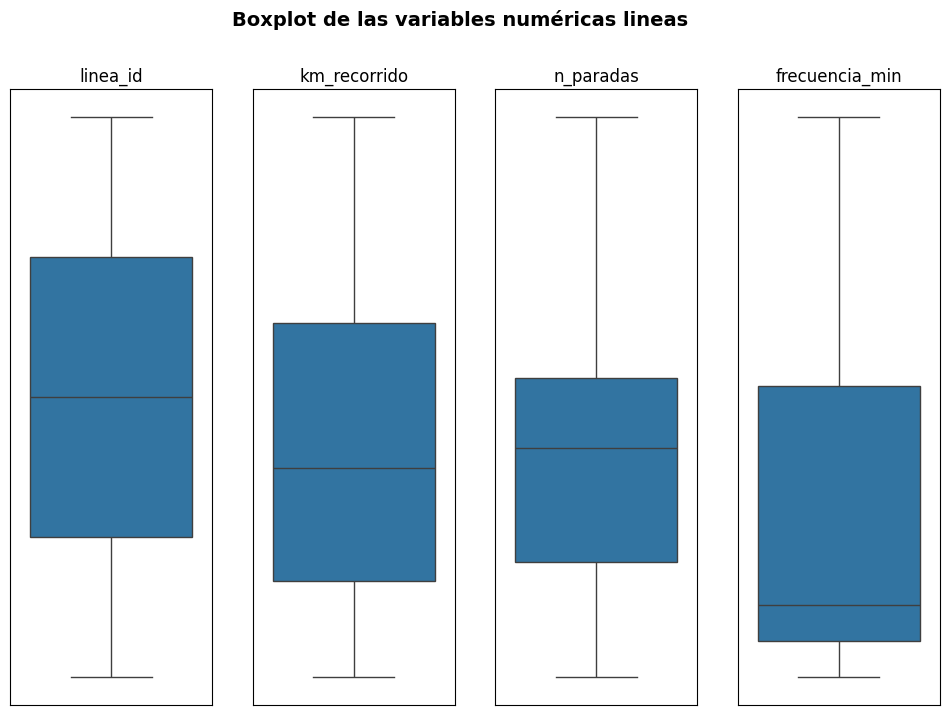

In [184]:
crear_boxplot_general(df_lineas.select_dtypes(include="number"), 4, "lineas")

Observando las diferentes gráficas, se puede apreciar que las variables **no presentan valores atípicos** (outliers). Por este motivo, no se procederá a realizar un análisis individualizado de estas variables.

## **7.7 Paradas**

### **7.7.1 Analisis Inicial**

In [185]:
df_paradas.head(3)

,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
0,1,Parada Barrio Norte 1,Barrio Norte,Intermedia,40.431989,-3.699183,True,False,False,True
1,2,Parada Barrio Sur 2,Barrio Sur,Intermedia,40.403568,-3.692632,True,True,True,True
2,3,Parada Universidad 3,Universidad,Intermedia,40.419744,-3.723256,True,False,False,True


In [186]:
df_paradas_metadatos = crear_tabla_metadatos(df_paradas)
df_paradas_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
marquesina,bool,0,0.00,2,120,10,0.62,0.48,True,False,True,NaN,NaN,"False, True"
panel_informacion,bool,0,0.00,2,120,10,0.50,0.50,False - True,False,True,NaN,NaN,"False, True"
activa,bool,0,0.00,2,120,10,0.96,0.20,True,False,True,NaN,NaN,"True, False"
parada_id,int64,0,0.00,120,120,10,60.50,34.64,1 - 2 - 3 - 4 - 5 - 6 - ...,1,120,NaN,NaN,"1, 2, 3"
latitud,float64,1,0.83,120,120,10,48.47,87.50,40.387789 - 40.388248 - 40.38887 - 40.393481 - 40.394235 - 40.396946 - ...,40.387789,999.0,NaN,NaN,"40.431989, 40.403568, 40.419744"
longitud,float64,0,0.00,120,120,10,-3.70,0.02,-3.751602 - -3.751416 - -3.750475 - -3.746306 - -3.746017 - -3.745488 - ...,-3.751602,-3.658867,NaN,NaN,"-3.699183, -3.692632, -3.723256"
nombre_parada,object,0,0.00,120,120,10,NaN,NaN,NaN,NaN,NaN,Parada Barrio Norte 1,1.0,"Parada Barrio Norte 1, Parada Barrio Sur 2, Parada Universidad 3"
barrio,object,0,0.00,13,120,10,NaN,NaN,NaN,NaN,NaN,Barrio Norte,11.0,"Barrio Norte, Barrio Sur, Universidad"
tipo,object,0,0.00,3,120,10,NaN,NaN,NaN,NaN,NaN,Intermedia,108.0,"Intermedia, Intercambiador, Cabecera"


In [187]:
df_paradas.accesible_silla.unique()

array([True, False, nan], dtype=object)

In [188]:
df_paradas.latitud.max()

np.float64(999.0)

In [189]:
df_paradas.barrio.unique()

array(['Barrio Norte', 'Barrio Sur', 'Universidad', 'Hospital', 'centro',
       'Estacion', 'Zona Comercial', 'Aeropuerto', 'Pueblo Oeste',
       'Pueblo Este', 'Centro', 'Poligono', 'BARRIO NORTE'], dtype=object)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_paradas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **latitud** presenta 1 valor nulo (0,83 %). Del mismo modo, la columna **accesible_silla** también contiene 1 valor nulo (0,83 %).

* La variable **accesible_silla** está almacenada con tipo de dato object, aunque únicamente contiene valores booleanos (True y False). 

* La columna **latitud** presenta un valor máximo de 999.0, claramente fuera del rango válido para una coordenada geográfica. 

* La variable **barrio** presenta inconsistencias en la estandarización de sus valores, ya que existen registros que hacen referencia a una misma categoría pero aparecen representados de diferentes formas. Por ejemplo, valores como 'Barrio Norte' y 'BARRIO NORTE'.

### **7.7.2 Outliers**

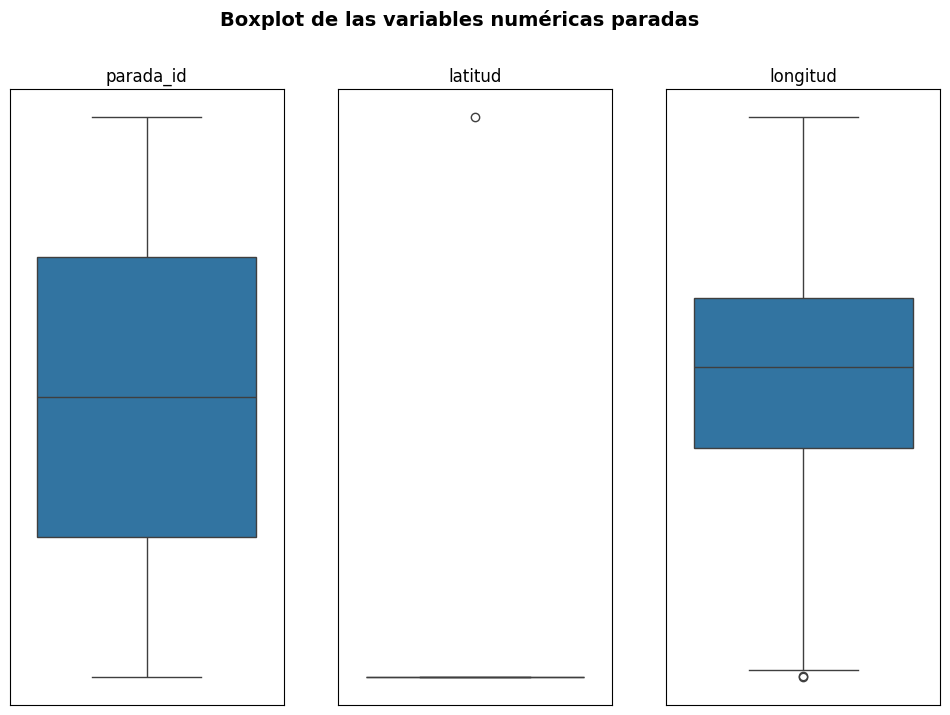

In [190]:
crear_boxplot_general(df_paradas.select_dtypes(include="number"), 3, "paradas")


Observando las diferentes gráficas, se puede apreciar que las variables **`Latitud`** y **`Longitud`** presentan valores atípicos (outliers). Por este motivo, se procederá a realizar un análisis individualizado de estas variables para determinar su origen y evaluar su impacto en el análisis de los datos.

## **7.8 Tarifas**

### **7.8.1 Analisis Inicial**

In [191]:
df_tarifas.head(9)

,tarifa_id,tipo_titulo,categoria,precio_eur,es_abono,bonificado
0,1,Ordinario,Adulto,1.50,False,False
1,2,Bono 10 Viajes,Adulto,0.97,True,False
2,3,Abono Mensual,Adulto,0.60,True,False
3,4,Abono Joven,Joven,0.40,True,True
4,5,Abono Jubilado,Jubilado,0.25,True,True
5,6,Gratuito Social,Social,0.00,True,True
6,7,Turistico 1 dia,Turista,5.00,False,False
7,8,Turistico 3 dias,Turista,10.00,False,False
8,9,Escolar,Escolar,0.20,True,True


In [192]:
df_tarifas_metadatos = crear_tabla_metadatos(df_tarifas)
df_tarifas_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
es_abono,bool,0,0.0,2,9,6,0.67,0.47,True,False,True,NaN,NaN,"False, True"
bonificado,bool,0,0.0,2,9,6,0.44,0.50,False,False,True,NaN,NaN,"False, True"
tarifa_id,int64,0,0.0,9,9,6,5.00,2.58,1 - 2 - 3 - 4 - 5 - 6 - ...,1,9,NaN,NaN,"1, 2, 3"
precio_eur,float64,0,0.0,9,9,6,2.10,3.15,0.0 - 0.2 - 0.25 - 0.4 - 0.6 - 0.97 - ...,0.0,10.0,NaN,NaN,"1.5, 0.97, 0.6"
tipo_titulo,object,0,0.0,9,9,6,NaN,NaN,NaN,NaN,NaN,Ordinario,1.0,"Ordinario, Bono 10 Viajes, Abono Mensual"
categoria,object,0,0.0,6,9,6,NaN,NaN,NaN,NaN,NaN,Adulto,3.0,"Adulto, Joven, Jubilado"


In [193]:
df_tarifas[df_tarifas['precio_eur'] == 0.0]

,tarifa_id,tipo_titulo,categoria,precio_eur,es_abono,bonificado
5,6,Gratuito Social,Social,0.0,True,True


## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_tarifas` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente.

In [194]:
df_tarifas.head(9)

,tarifa_id,tipo_titulo,categoria,precio_eur,es_abono,bonificado
0,1,Ordinario,Adulto,1.50,False,False
1,2,Bono 10 Viajes,Adulto,0.97,True,False
2,3,Abono Mensual,Adulto,0.60,True,False
3,4,Abono Joven,Joven,0.40,True,True
4,5,Abono Jubilado,Jubilado,0.25,True,True
5,6,Gratuito Social,Social,0.00,True,True
6,7,Turistico 1 dia,Turista,5.00,False,False
7,8,Turistico 3 dias,Turista,10.00,False,False
8,9,Escolar,Escolar,0.20,True,True


### **7.8.2 Outliers**

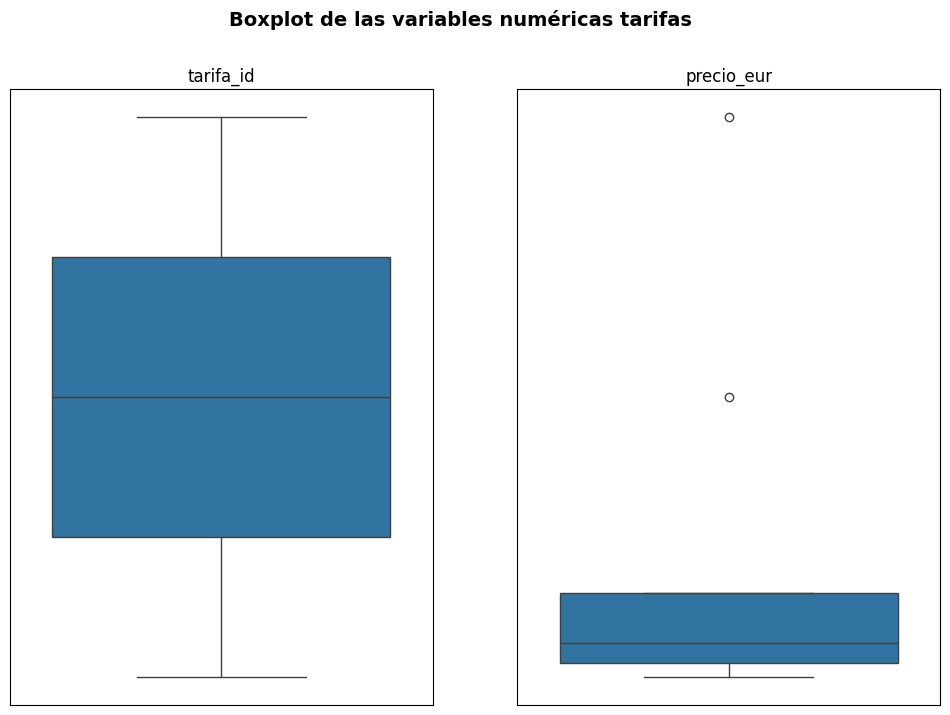

In [195]:
crear_boxplot_general(df_tarifas.select_dtypes(include="number"), 2, "tarifas")

#### **7.8.2.1 Precio euros**

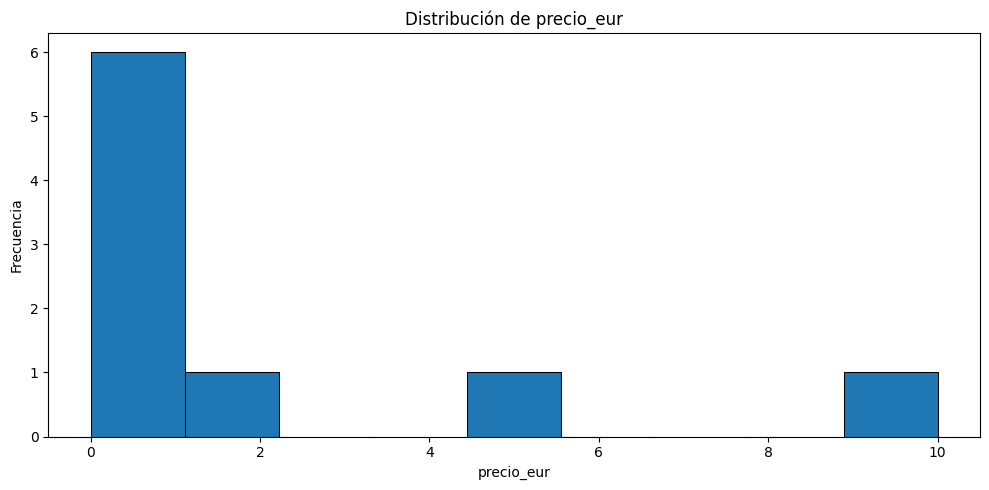

In [196]:
crear_histograma(df_tarifas, "precio_eur")

In [197]:
calcular_iqr(df_tarifas, "precio_eur")


Valores atípicos detectados con IQR: 2


6     5.0
7    10.0
Name: precio_eur, dtype: float64

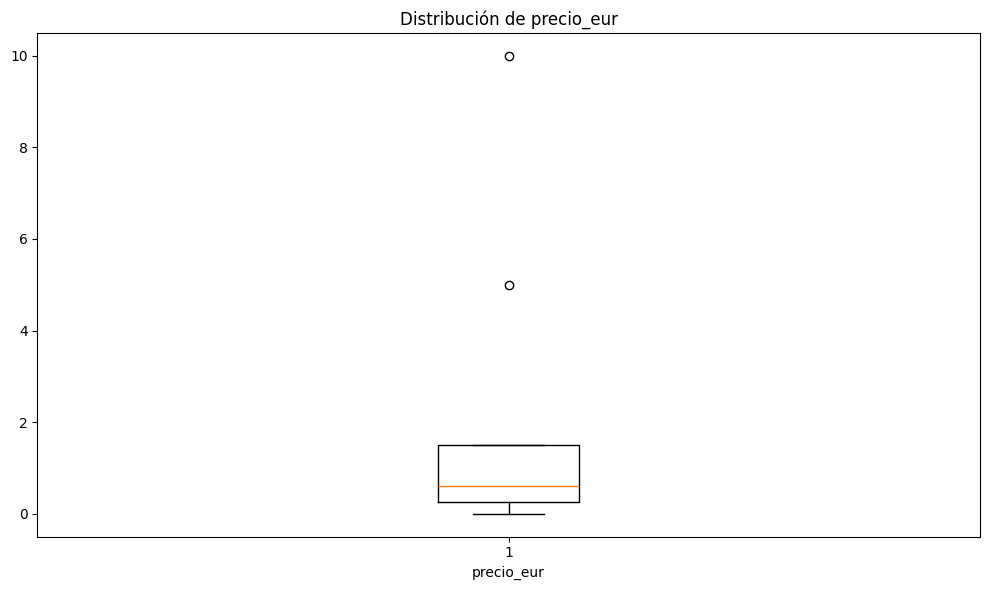

In [199]:
crear_boxplot(df_tarifas, "precio_eur")

## **7.9 Vehiculos**

### **7.9.1 Analisis Inicial**

In [200]:
df_vehiculos.head(3)

,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
0,1,6001 BUS,Mercedes-Benz Citaro,Diesel,88,128,2017,2018,586265,1,127,True
1,2,6002 BUS,Mercedes-Benz Citaro,Diesel,88,128,2018,2019,317095,1,112,True
2,3,6003 BUS,Iveco Urbanway,diesel,90,130,2018,2019,256606,2,133,True


In [201]:
df_vehiculos_metadatos = crear_tabla_metadatos(df_vehiculos)
df_vehiculos_metadatos

,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Filas,Columnas,Media,Desviacion,Moda,Minimo,Maximo,Top,Frecuencia_Moda,Ejemplo de Valores (Max.3)
Columna,,,,,,,,,,,,,,
en_servicio,bool,0,0.00,2,45,12,0.93,0.25,True,False,True,NaN,NaN,"True, False"
vehiculo_id,int64,0,0.00,45,45,12,23.00,12.99,1 - 2 - 3 - 4 - 5 - 6 - ...,1,45,NaN,NaN,"1, 2, 3"
capacidad_sentados,int64,0,0.00,5,45,12,95.20,18.65,88,85,145,NaN,NaN,"88, 90, 85"
capacidad_total,int64,0,0.00,5,45,12,135.20,18.65,128,125,185,NaN,NaN,"128, 130, 125"
anno_fabricacion,int64,0,0.00,12,45,12,2020.82,12.09,2020,2014,2099,NaN,NaN,"2017, 2018, 2019"
anno_incorporacion,int64,0,0.00,11,45,12,2020.13,2.76,2021,2015,2025,NaN,NaN,"2018, 2019, 2020"
km_totales,int64,0,0.00,45,45,12,361823.53,155598.62,-500 - 78276 - 78418 - 80434 - 92213 - 138914 - ...,-500,596622,NaN,NaN,"586265, 317095, 256606"
depot_id,int64,0,0.00,3,45,12,1.87,0.75,2,1,3,NaN,NaN,"1, 2, 3"
emisiones_co2_gkm,int64,0,0.00,24,45,12,83.47,53.42,0,0,140,NaN,NaN,"127, 112, 133"


In [202]:
df_vehiculos['anno_fabricacion'].unique()

array([2017, 2018, 2019, 2014, 2020, 2099, 2024, 2021, 2016, 2022, 2015,
       2023])

In [203]:
df_vehiculos['km_totales'].unique()

array([586265, 317095, 256606, 379164, 581756, 360016, 447562, 365568,
       368635, 387902, 274082, 138914, 401470, 285552, 548216,   -500,
       305836, 495798, 537115, 528634, 382711, 579298, 216889, 309249,
       596622, 511239, 402161, 292495, 274345, 538557, 458396, 448858,
       458930, 281251,  80434, 223061,  78276,  78418, 534125, 393254,
       447542, 543152, 285113,  92213, 209784])

In [204]:
df_vehiculos[df_vehiculos['emisiones_co2_gkm'] == 0]

,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
6,7,6007 BUS,BYD eBus-12,Electrico,90,130,2020,2021,447562,3,0,True
7,8,6008 BUS,BYD eBus-12,Electrico,90,130,2099,2024,365568,2,0,True
8,9,6009 BUS,Irizar ie bus,Electrico,85,125,2024,2025,368635,2,0,True
13,14,6014 BUS,Mercedes-Benz eCitaro,Electrico,85,125,2022,2023,285552,1,0,True
21,22,6022 BUS,BYD eBus-12,Electrico,90,130,2022,2023,579298,2,0,True
22,23,6023 BUS,BYD eBus-12,Electrico,90,130,2023,2024,216889,3,0,True
23,24,6024 BUS,Irizar ie bus,Electrico,85,125,2023,2024,309249,3,0,True
28,29,6029 BUS,Mercedes-Benz eCitaro,Electrico,85,125,2024,2025,274345,1,0,True
36,37,6037 BUS,BYD eBus-12,Electrico,90,130,2020,2021,78276,2,0,True
37,38,6038 BUS,BYD eBus-12,Electrico,90,130,2023,2024,78418,1,0,True


In [205]:
df_vehiculos['combustible'].unique()

array(['Diesel', 'diesel', 'Electrico', 'Hibrido', nan], dtype=object)

## **Hallazgos iniciales**

El análisis de los metadatos del DataFrame `df_vehiculos` permite concluir que, en términos generales, la tabla presenta una calidad de datos aceptable. Todas las variables contienen información completa y los valores registrados mantienen una estructura coherente. La mayoría de las variables contienen información completa y los valores registrados mantienen una estructura coherente. No obstante, se han identificado algunos aspectos que requieren una revisión más detallada durante las siguientes fases del EDA:

* La columna **año_fabricacion** presenta un valor máximo de 2099, un dato claramente incoherente que deberá verificarse, ya que probablemente corresponda a un error de captura o de generación de los datos.

* La variable **km_totales** contiene un valor mínimo de -500 km, un registro imposible desde el punto de vista operativo.

* La columna **emisiones_co2_gkm** presenta valores iguales a 0 g/km. Tras revisar el conjunto de datos, se observa que estos registros corresponden a vehículos eléctricos.

* La variable **combustible** presenta una falta de estandarización en sus categorías, ya que aparecen los valores Diesel y diesel, que representan el mismo tipo de combustible.

### **7.9.2 Outliers**

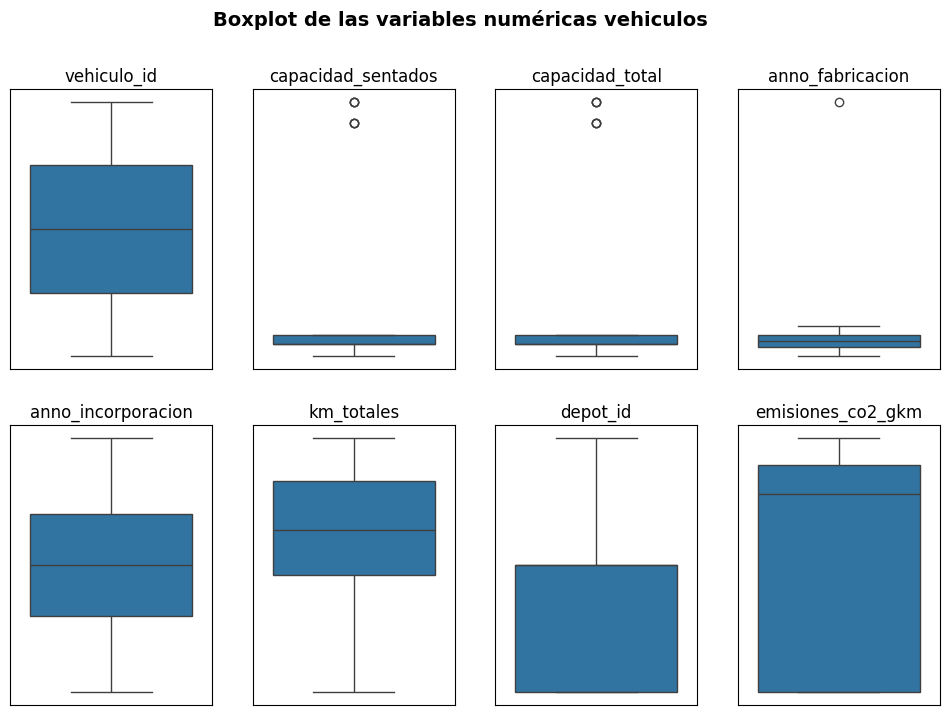

In [206]:
crear_boxplot_general(df_vehiculos.select_dtypes(include="number"), 4, "vehiculos")

Observando las diferentes gráficas, se puede apreciar que las variables **`Capacidad sentados`**, **`Capacidad total`** y **`Año fabricación`** presentan valores atípicos (outliers). Por este motivo, se procederá a realizar un análisis individualizado de **`Capacidad sentados`** y **`Capacidad total`** para determinar su origen y evaluar su impacto en el análisis de los datos.

#### **7.9.2.1 Capacidad sentados**

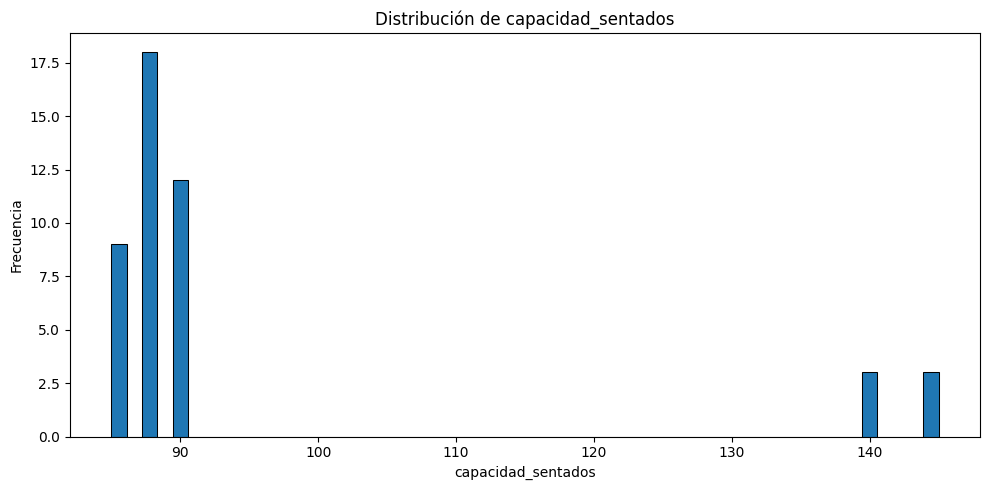

In [207]:
crear_histograma(df_vehiculos, "capacidad_sentados")

In [208]:
calcular_iqr(df_vehiculos, "capacidad_sentados")


Valores atípicos detectados con IQR: 6


5     145
12    140
20    145
27    140
35    145
42    140
Name: capacidad_sentados, dtype: int64

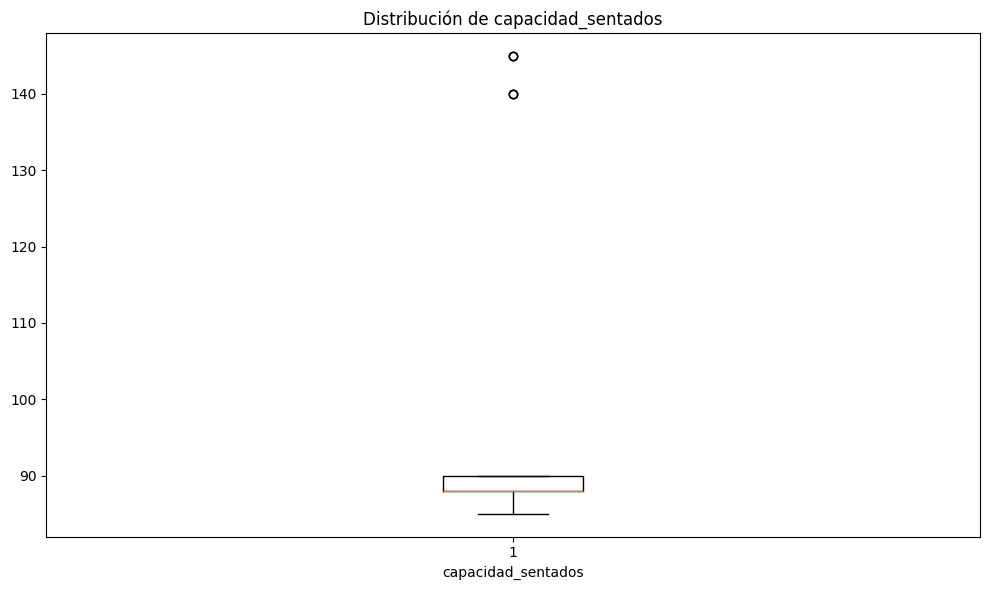

In [210]:
crear_boxplot(df_vehiculos, "capacidad_sentados")

#### **7.9.2.1 Capacidad total**

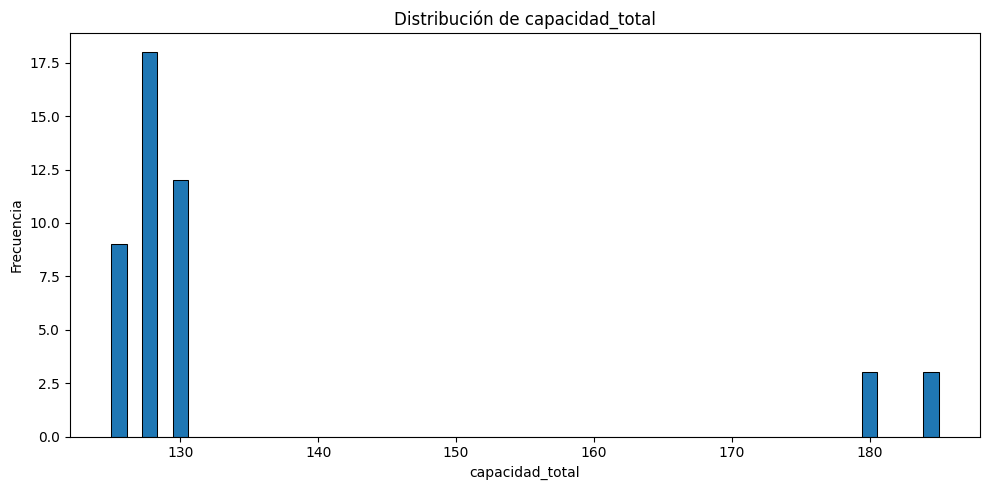

In [211]:
crear_histograma(df_vehiculos, "capacidad_total")

In [212]:
calcular_iqr(df_vehiculos, "capacidad_total")


Valores atípicos detectados con IQR: 6


5     185
12    180
20    185
27    180
35    185
42    180
Name: capacidad_total, dtype: int64

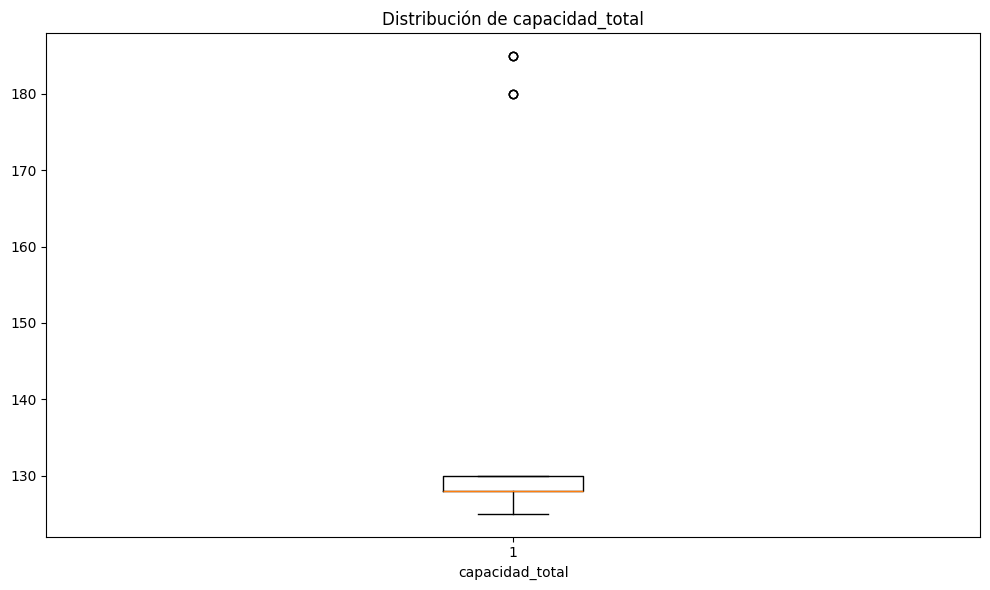

In [214]:
crear_boxplot(df_vehiculos, "capacidad_total")

## **8. Conclusión**